In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/imdb_features.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7919, 72)


,name,year,duration,genre,main_genre,rating,votes,director,actor_1,actor_2,...,genre_horror.1,genre_music.1,genre_musical.1,genre_mystery.1,genre_romance.1,genre_sci-fi.1,genre_sport.1,genre_thriller.1,genre_unknown,genre_war.1
0,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,...,0,0,0,0,0,0,0,0,0,0
1,#Yaaram,2019.0,110.0,"Comedy, Romance",Comedy,4.4,35.0,Ovais Khan,Prateik,Ishita Raj,...,0,0,0,0,0,0,0,0,0,0
2,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",Comedy,4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,...,0,0,0,0,0,0,0,0,0,0
3,...Yahaan,2005.0,142.0,"Drama, Romance, War",Drama,7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,...,0,0,0,0,0,0,0,0,0,0
4,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",Horror,5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,...,1,0,0,0,0,0,0,0,0,0


In [3]:
print(df.columns.tolist())

['name', 'year', 'duration', 'genre', 'main_genre', 'rating', 'votes', 'director', 'actor_1', 'actor_2', 'actor_3', 'duration_missing', 'votes_missing', 'year_missing', 'director_missing', 'actor_1_missing', 'movie_age', 'genre_count', 'runtime_category', 'log_votes', 'popular_movie', 'highly_popular_movie', 'vote_percentile', 'director_experience', 'director_avg_rating', 'lead_actor_experience', 'lead_actor_avg_rating', 'genre_frequency', 'runtime_Long', 'runtime_Medium', 'runtime_Short', 'genre_action', 'genre_adventure', 'genre_biography', 'genre_comedy', 'genre_crime', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_history', 'genre_horror', 'genre_music', 'genre_musical', 'genre_mystery', 'genre_news', 'genre_romance', 'genre_sci-fi', 'genre_sport', 'genre_thriller', 'genre_war', 'genre_western', 'genre_action.1', 'genre_adventure.1', 'genre_animation', 'genre_biography.1', 'genre_comedy.1', 'genre_crime.1', 'genre_documentary', 'genre_drama.1', 'genre_family.1', 'genre_fan

In [4]:
drop_cols = [
    "name", "genre", "main_genre", "director",
    "actor_1", "actor_2", "actor_3", "runtime_category"
]

df_model = df.drop(columns=drop_cols, errors="ignore")

display(df_model.head())
print(df_model.shape)

,year,duration,rating,votes,duration_missing,votes_missing,year_missing,director_missing,actor_1_missing,movie_age,...,genre_horror.1,genre_music.1,genre_musical.1,genre_mystery.1,genre_romance.1,genre_sci-fi.1,genre_sport.1,genre_thriller.1,genre_unknown,genre_war.1
0,2019.0,109.0,7.0,8.0,0,0,0,0,0,7.0,...,0,0,0,0,0,0,0,0,0,0
1,2019.0,110.0,4.4,35.0,0,0,0,0,0,7.0,...,0,0,0,0,0,0,0,0,0,0
2,1997.0,147.0,4.7,827.0,0,0,0,0,0,29.0,...,0,0,0,0,0,0,0,0,0,0
3,2005.0,142.0,7.4,1086.0,0,0,0,0,0,21.0,...,0,0,0,0,0,0,0,0,0,0
4,2012.0,82.0,5.6,326.0,0,0,0,0,0,14.0,...,1,0,0,0,0,0,0,0,0,0


(7919, 64)


In [5]:
X = df_model.drop("rating", axis=1)
y = df_model["rating"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7919, 63)
y shape: (7919,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6335, 63)
Testing set: (1584, 63)


In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [8]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

results = []

results.append({
    "Model": "Baseline Mean Model",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2 Score": baseline_r2
})

results

[{'Model': 'Baseline Mean Model',
  'MAE': 1.1072005074422202,
  'RMSE': np.float64(1.364534778211662),
  'R2 Score': -0.0015114582746571514}]

In [9]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

results.append(
    evaluate_model(
        linear_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Linear Regression"
    )
)

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

results.append(
    evaluate_model(
        rf_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Random Forest Regressor"
    )
)

In [11]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

results.append(
    evaluate_model(
        gb_model,
        X_train,
        X_test,
        y_train,
        y_test,
        "Gradient Boosting Regressor"
    )
)

In [12]:
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    results.append(
        evaluate_model(
            xgb_model,
            X_train,
            X_test,
            y_train,
            y_test,
            "XGBoost Regressor"
        )
    )

    print("XGBoost trained successfully!")

except ImportError:
    print("XGBoost is not installed. Skipping XGBoost model.")

XGBoost trained successfully!


In [13]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")

display(results_df)

,Model,MAE,RMSE,R2 Score
4,XGBoost Regressor,0.451944,0.661433,0.764680
2,Random Forest Regressor,0.434922,0.677021,0.753458
3,Gradient Boosting Regressor,0.487069,0.694221,0.740772
1,Linear Regression,0.544592,0.745727,0.700879
0,Baseline Mean Model,1.107201,1.364535,-0.001511


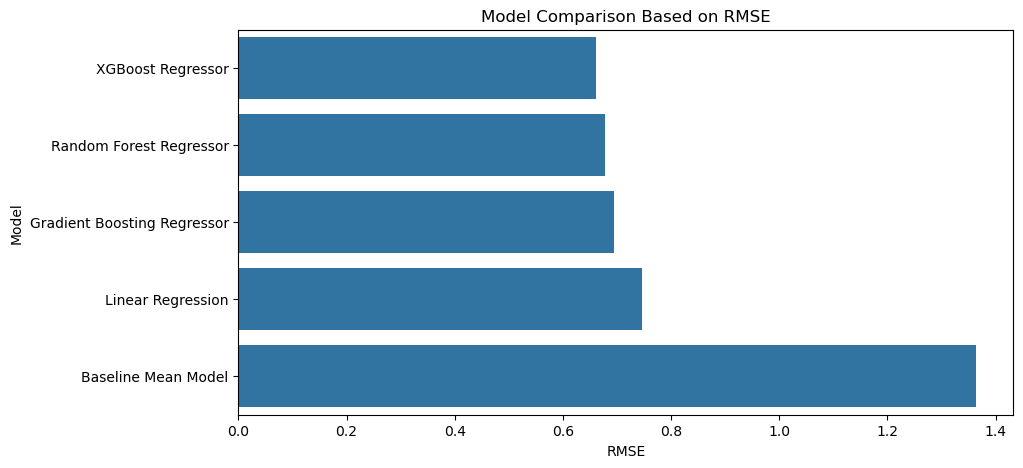

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="RMSE", y="Model")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost Regressor


In [16]:
from xgboost import XGBRegressor

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

print("Best CV RMSE:", -xgb_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV RMSE: 0.6541483831090724


In [17]:
best_xgb_model = xgb_search.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("Tuned XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

Tuned XGBoost Results
MAE: 0.4307360516955154
RMSE: 0.6512645338543237
R2 Score: 0.7718599350936629


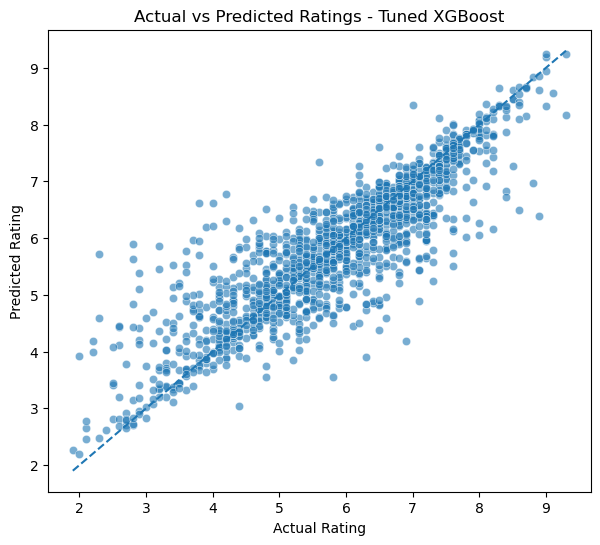

In [18]:
plt.figure(figsize=(7, 6))

sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings - Tuned XGBoost")
plt.show()

In [19]:
residuals = y_test - y_pred_xgb

residual_df = pd.DataFrame({
    "Actual Rating": y_test,
    "Predicted Rating": y_pred_xgb,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals)
})

display(residual_df.head())

,Actual Rating,Predicted Rating,Residual,Absolute Error
4896,3.3,3.375175,-0.075175,0.075175
7538,5.3,4.861599,0.438401,0.438401
1677,5.7,4.831399,0.868601,0.868601
1964,7.2,5.641441,1.558559,1.558559
3025,3.5,3.449247,0.050753,0.050753


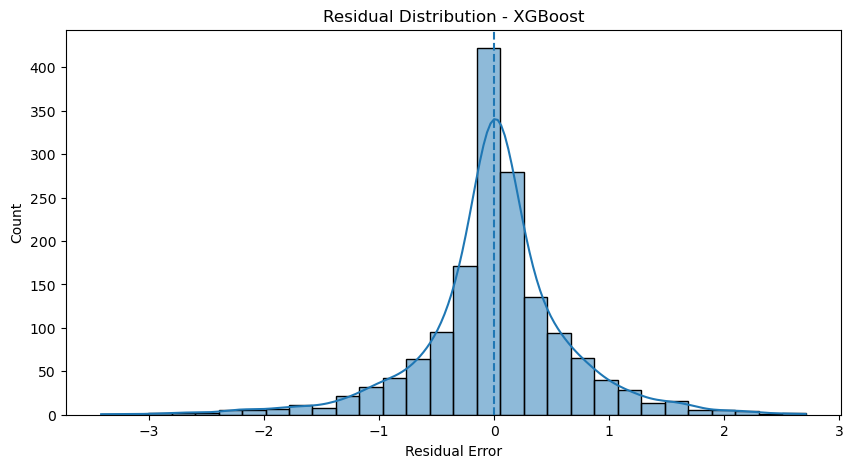

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(residual_df["Residual"], bins=30, kde=True)

plt.axvline(0, linestyle="--")

plt.title("Residual Distribution - XGBoost")
plt.xlabel("Residual Error")
plt.ylabel("Count")
plt.show()

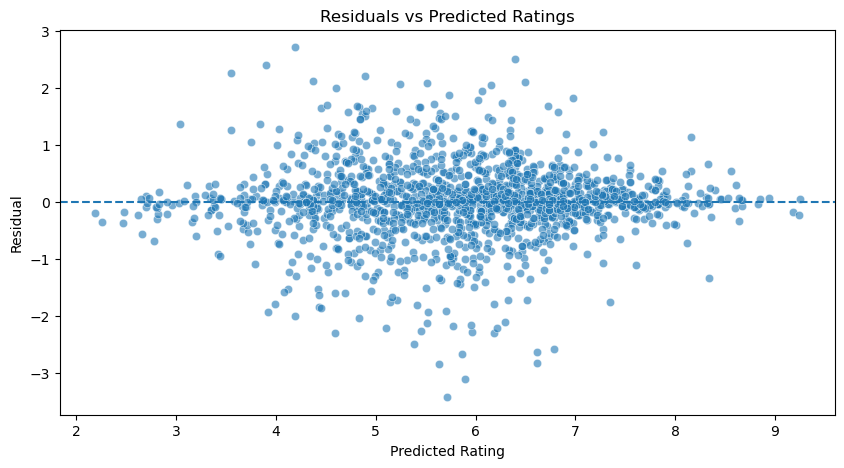

In [21]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x=residual_df["Predicted Rating"],
    y=residual_df["Residual"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Ratings")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.show()

In [22]:
def error_bucket(error):
    if error <= 0.5:
        return "Excellent (≤ 0.5)"
    elif error <= 1.0:
        return "Good (0.5 - 1.0)"
    elif error <= 1.5:
        return "Moderate (1.0 - 1.5)"
    else:
        return "High Error (> 1.5)"

residual_df["Error Bucket"] = residual_df["Absolute Error"].apply(error_bucket)

error_summary = residual_df["Error Bucket"].value_counts().reset_index()
error_summary.columns = ["Error Bucket", "Count"]

display(error_summary)

,Error Bucket,Count
0,Excellent (≤ 0.5),1106
1,Good (0.5 - 1.0),294
2,Moderate (1.0 - 1.5),108
3,High Error (> 1.5),76


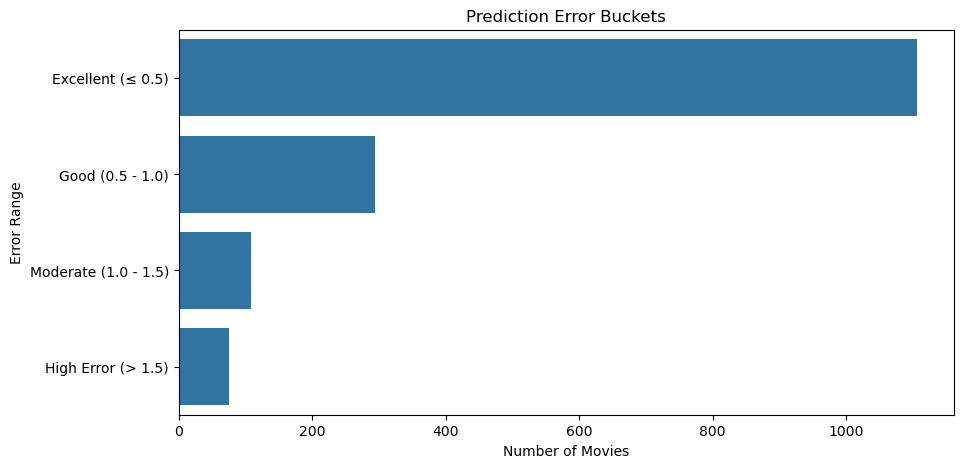

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=error_summary,
    x="Count",
    y="Error Bucket"
)

plt.title("Prediction Error Buckets")
plt.xlabel("Number of Movies")
plt.ylabel("Error Range")
plt.show()

In [24]:
best_predictions = residual_df.sort_values("Absolute Error").head(10)

display(best_predictions)

,Actual Rating,Predicted Rating,Residual,Absolute Error,Error Bucket
6458,7.0,7.000020,-0.000020,0.000020,Excellent (≤ 0.5)
5245,6.6,6.600094,-0.000094,0.000094,Excellent (≤ 0.5)
435,6.6,6.599635,0.000365,0.000365,Excellent (≤ 0.5)
1897,6.6,6.599578,0.000422,0.000422,Excellent (≤ 0.5)
2110,7.2,7.200589,-0.000589,0.000589,Excellent (≤ 0.5)
4674,7.9,7.898862,0.001138,0.001138,Excellent (≤ 0.5)
2432,4.3,4.301484,-0.001484,0.001484,Excellent (≤ 0.5)
3260,5.8,5.802299,-0.002299,0.002299,Excellent (≤ 0.5)
6173,6.4,6.402326,-0.002326,0.002326,Excellent (≤ 0.5)
2699,7.1,7.097580,0.002420,0.002420,Excellent (≤ 0.5)


In [25]:
worst_predictions = residual_df.sort_values("Absolute Error", ascending=False).head(10)

display(worst_predictions)

,Actual Rating,Predicted Rating,Residual,Absolute Error,Error Bucket
1656,2.3,5.717273,-3.417273,3.417273,High Error (> 1.5)
233,2.8,5.895783,-3.095783,3.095783,High Error (> 1.5)
217,2.8,5.629776,-2.829776,2.829776,High Error (> 1.5)
2301,3.8,6.611665,-2.811665,2.811665,High Error (> 1.5)
6747,6.9,4.192114,2.707886,2.707886,High Error (> 1.5)
7539,3.2,5.866750,-2.666750,2.666750,High Error (> 1.5)
6860,4.0,6.618981,-2.618981,2.618981,High Error (> 1.5)
5304,4.2,6.781410,-2.581410,2.581410,High Error (> 1.5)
4418,8.9,6.394351,2.505649,2.505649,High Error (> 1.5)
3428,2.9,5.384786,-2.484786,2.484786,High Error (> 1.5)


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

,Feature,Importance
15,director_avg_rating,0.318459
17,lead_actor_avg_rating,0.071622
12,highly_popular_movie,0.065394
44,genre_animation,0.027034
2,votes,0.026124
7,actor_1_missing,0.023793
29,genre_fantasy,0.019444
40,genre_war,0.018642
42,genre_action.1,0.017862
16,lead_actor_experience,0.017560


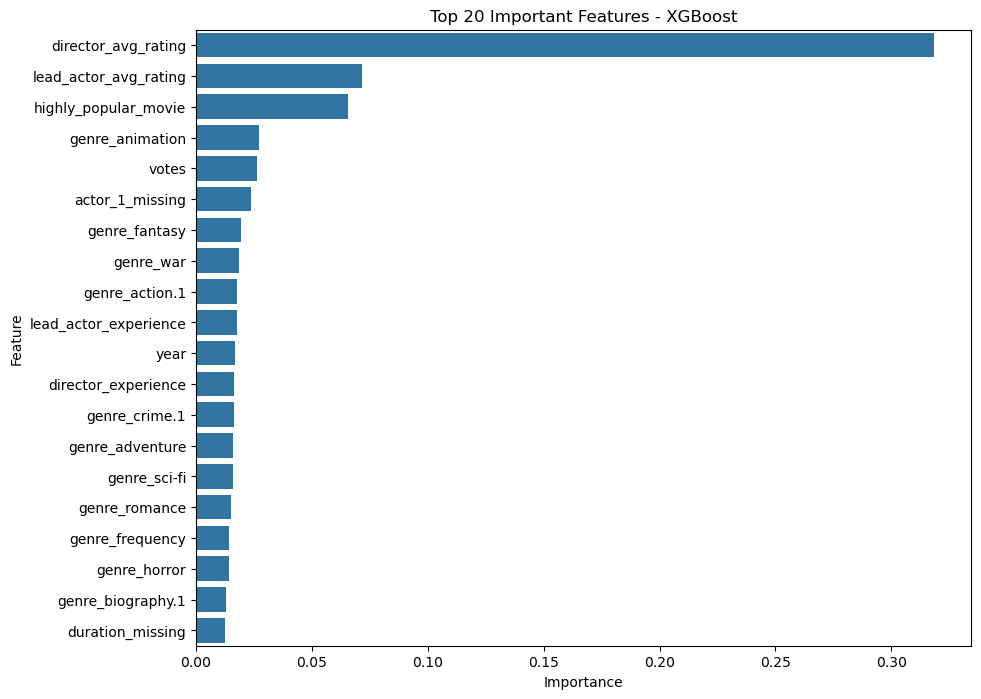

In [27]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [28]:
cv_scores = cross_val_score(
    best_xgb_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse_scores = -cv_scores

print("Cross Validation RMSE Scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())
print("Standard Deviation:", cv_rmse_scores.std())

Cross Validation RMSE Scores: [0.63826794 0.63493472 0.65332389 0.66619252 0.65757668]
Mean CV RMSE: 0.6500591479857973
Standard Deviation: 0.01179184806423116


In [29]:
os.makedirs("../models", exist_ok=True)

joblib.dump(best_xgb_model, "../models/movie_rating_xgb_model.pkl")
joblib.dump(X_train.columns.tolist(), "../models/model_features.pkl")

print("Final XGBoost model saved successfully!")

Final XGBoost model saved successfully!


In [30]:
results_df.to_csv("../models/model_comparison_results.csv", index=False)
feature_importance.to_csv("../models/feature_importance_xgb.csv", index=False)
residual_df.to_csv("../models/xgb_residual_analysis.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!


In [31]:
cv_summary = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "RMSE": cv_rmse_scores
})

display(cv_summary)

print(f"Average RMSE : {cv_rmse_scores.mean():.4f}")
print(f"Std. Dev     : {cv_rmse_scores.std():.4f}")

,Fold,RMSE
0,1,0.638268
1,2,0.634935
2,3,0.653324
3,4,0.666193
4,5,0.657577


Average RMSE : 0.6501
Std. Dev     : 0.0118


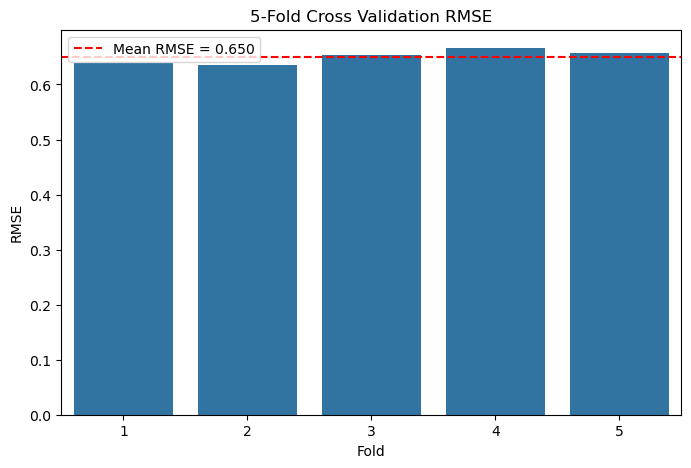

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cv_summary,
    x="Fold",
    y="RMSE"
)

plt.axhline(
    cv_rmse_scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean RMSE = {cv_rmse_scores.mean():.3f}"
)

plt.title("5-Fold Cross Validation RMSE")
plt.ylabel("RMSE")
plt.legend()

plt.show()

In [33]:
performance = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score",
        "CV Mean RMSE",
        "CV Std Dev"
    ],
    "Value": [
        round(xgb_mae, 4),
        round(xgb_rmse, 4),
        round(xgb_r2, 4),
        round(cv_rmse_scores.mean(), 4),
        round(cv_rmse_scores.std(), 4)
    ]
})

display(performance)

,Metric,Value
0,MAE,0.4307
1,RMSE,0.6513
2,R² Score,0.7719
3,CV Mean RMSE,0.6501
4,CV Std Dev,0.0118


In [34]:
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"Model                 : Tuned XGBoost Regressor")
print(f"MAE                   : {xgb_mae:.4f}")
print(f"RMSE                  : {xgb_rmse:.4f}")
print(f"R² Score              : {xgb_r2:.4f}")
print(f"Mean CV RMSE          : {cv_rmse_scores.mean():.4f}")
print(f"CV Standard Deviation : {cv_rmse_scores.std():.4f}")

print("\nInterpretation:")
print(f"• The model predicts movie ratings with an average error of approximately {xgb_mae:.2f} rating points.")
print(f"• It explains about {xgb_r2 * 100:.2f}% of the variation in movie ratings.")
print("• The low cross-validation standard deviation indicates stable and consistent performance across different data splits.")

FINAL MODEL SUMMARY
Model                 : Tuned XGBoost Regressor
MAE                   : 0.4307
RMSE                  : 0.6513
R² Score              : 0.7719
Mean CV RMSE          : 0.6501
CV Standard Deviation : 0.0118

Interpretation:
• The model predicts movie ratings with an average error of approximately 0.43 rating points.
• It explains about 77.19% of the variation in movie ratings.
• The low cross-validation standard deviation indicates stable and consistent performance across different data splits.
